<a href="https://colab.research.google.com/github/Ali13fffff/hotel-booking-cancellation-analysis/blob/main/%F0%9F%8F%A8Hotel_booking_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancellation Analysis

Hello everyone, my name is Ali. I am a Data Analyst and Data Scientist.

In this project, I will explore and analyze a hotel booking dataset to better understand the factors that contribute to booking cancellations.

Our main objective is to use data-driven insights to help the hotel minimize its cancellation rate and prevent potential revenue leakage.

Throughout this project, we will examine customer behavior, booking characteristics, cancellation patterns, and other relevant factors. The findings will help us develop practical business recommendations for improving hotel revenue and operational efficiency.

Stay with me as we explore the data and uncover valuable insights.✍📊📊

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving booking.csv to booking.csv


#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load The Data

In [ ]:
df=pd.read_csv("booking.csv")
print(df.head())
print(df.describe())
print(df.info())

  Booking_ID  number of adults  number of children  number of weekend nights  \
0   INN00001                 1                   1                         2   
1   INN00002                 1                   0                         1   
2   INN00003                 2                   1                         1   
3   INN00004                 1                   0                         0   
4   INN00005                 1                   0                         1   

   number of week nights  type of meal  car parking space    room type  \
0                      5   Meal Plan 1                  0  Room_Type 1   
1                      3  Not Selected                  0  Room_Type 1   
2                      3   Meal Plan 1                  0  Room_Type 1   
3                      2   Meal Plan 1                  0  Room_Type 1   
4                      2  Not Selected                  0  Room_Type 1   

   lead time market segment type  repeated  P-C  P-not-C  average price  \

#Cleaning The Data

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())
df=df.drop(columns="Booking_ID")

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64
0


## Target Variable Analysis: Booking Status

After loading and cleaning the dataset, we will analyze the target variable, `booking status`.

First, we will examine the number of canceled and non-canceled bookings. This will help us understand the overall cancellation pattern in the dataset.

We will then investigate whether booking cancellations have an impact on the hotel’s potential revenue. This analysis can help us estimate the possible revenue loss caused by cancellations and provide a better understanding of their business impact.

In [ ]:

# Create potential revenue column
# Create total number of nights
df['total_nights'] = (
    df['number of weekend nights'] +
    df['number of week nights']
)


df['potential_revenue'] = df['total_nights'] * df['average price']

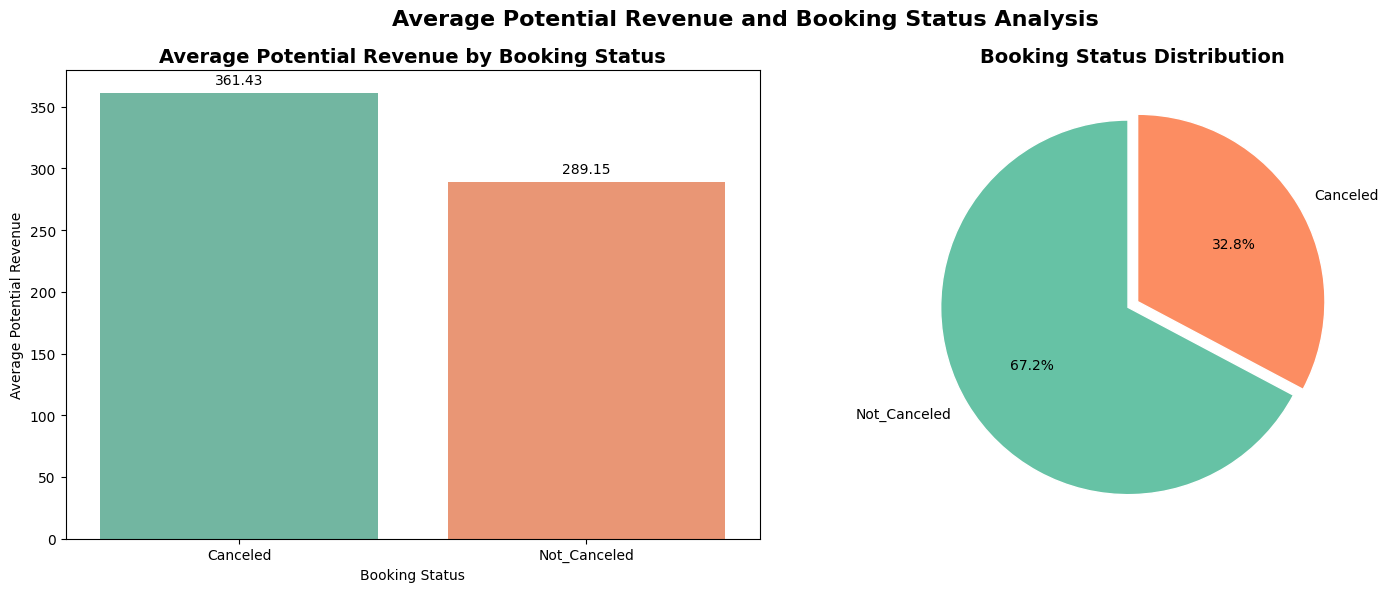

In [ ]:


# Calculate average potential revenue by booking status
average_revenue_by_status = (
    df.groupby('booking status')['potential_revenue']
      .mean()
      .sort_values(ascending=False)
)

# Count bookings by booking status
booking_counts = df['booking status'].value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --------------------------------
# 1. Bar Chart: Average Potential Revenue
# --------------------------------
ax1 = axes[0]

sns.barplot(
    x=average_revenue_by_status.index,
    y=average_revenue_by_status.values,
    ax=ax1,
    hue=average_revenue_by_status.index,
    palette='Set2',
    legend=False
)

ax1.set_title(
    'Average Potential Revenue by Booking Status',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Booking Status')
ax1.set_ylabel('Average Potential Revenue')

# Add value labels
for i, value in enumerate(average_revenue_by_status.values):
    ax1.text(
        i,
        value + average_revenue_by_status.max() * 0.02,
        f'{value:,.2f}',
        ha='center',
        fontsize=10
    )

# --------------------------------
# 2. Pie Chart: Booking Distribution
# --------------------------------
ax2 = axes[1]

colors = ['#66c2a5', '#fc8d62', '#8da0cb']

ax2.pie(
    booking_counts.values,
    labels=booking_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(booking_counts)],
    explode=[0.03] * len(booking_counts),
    wedgeprops={'edgecolor': 'white'}
)

ax2.set_title(
    'Booking Status Distribution',
    fontsize=14,
    fontweight='bold'
)

# Overall title
plt.suptitle(
    'Average Potential Revenue and Booking Status Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#Although canceled bookings account for only about 32.8% of all reservations, their average potential revenue is higher than that of not-canceled bookings. This suggests that cancellation is not only a volume issue but also a financial risk issue. In other words, the hotel is losing more valuable reservations, which can lead to a greater revenue impact than the cancellation rate alone implies.

## Temporal Analysis: Reservation Date, Month, and Day-of-Week Cancellation Patterns

In [ ]:
# Convert the reservation date column to datetime
df['date of reservation'] = pd.to_datetime(
    df['date of reservation'],
    errors='coerce'
)

# Display the result
df[['date of reservation']].head()

,date of reservation
0,2015-10-02
1,2018-11-06
2,2018-02-28
3,2017-05-20
4,2018-04-11


In [ ]:
# Create the day-of-week column
df['reservation_day_of_week'] = (
    df['date of reservation']
      .dt.day_name()
)

# Display the result
df[
    ['date of reservation', 'reservation_day_of_week']
].head()

,date of reservation,reservation_day_of_week
0,2015-10-02,Friday
1,2018-11-06,Tuesday
2,2018-02-28,Wednesday
3,2017-05-20,Saturday
4,2018-04-11,Wednesday


In [ ]:
# Ensure the date column is datetime
df['date of reservation'] = pd.to_datetime(df['date of reservation'], errors='coerce')

# Extract day name
df['reservation_day_of_week'] = df['date of reservation'].dt.day_name()

# Create a binary cancellation column if needed
# If your booking status is text like 'Canceled' and 'Not_Canceled':
df['booking_status_number'] = df['booking status'].map({
    'Canceled': 1,
    'Not_Canceled': 0
})

# Group by day of week
day_summary = df.groupby('reservation_day_of_week').agg(
    total_bookings=('booking_status_number', 'count'),
    total_canceled=('booking_status_number', 'sum'),
    cancellation_rate=('booking_status_number', 'mean')
)

# Convert cancellation rate to percentage
day_summary['cancellation_rate'] = day_summary['cancellation_rate'] * 100

# Sort by weekday order
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

day_summary = day_summary.reindex(weekday_order)

day_summary.round(2)

,total_bookings,total_canceled,cancellation_rate
reservation_day_of_week,,,
Monday,5380,1655,30.76
Tuesday,4901,1587,32.38
Wednesday,5123,1681,32.81
Thursday,4545,1430,31.46
Friday,4743,1507,31.77
Saturday,5420,1731,31.94
Sunday,6136,2291,37.34


/tmp/ipykernel_2268/3692581166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


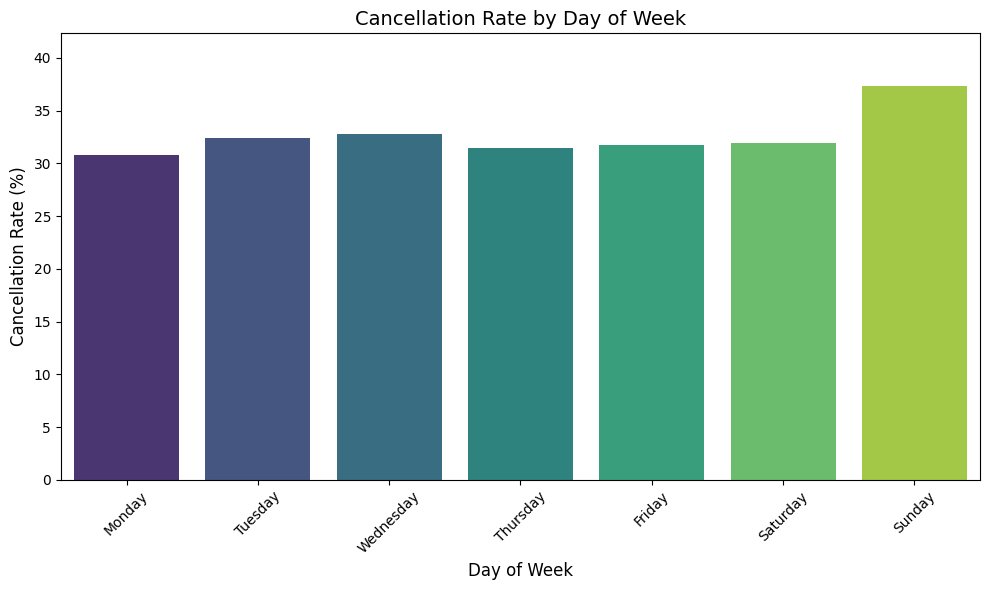

In [ ]:


plt.figure(figsize=(10, 6))
sns.barplot(
    x=day_summary.index,
    y=day_summary['cancellation_rate'],
    palette='viridis'
)

plt.title('Cancellation Rate by Day of Week', fontsize=14)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, day_summary['cancellation_rate'].max() + 5)
plt.tight_layout()
plt.show()

### Key Insights: Reservation Day of Week
* **Finding:** Sunday has the highest cancellation rate at **37.34%** compared to other days of the week.
* **Interpretation:** This represents an initial statistical correlation (signal), not proof of direct causation.
* **Next Steps & Recommendation:** Further multivariate analysis incorporating features such as `lead_time`, `customer_type`, and `deposit_type` is required before implementing any restrictive booking policies on Sundays.

In [ ]:
df['reservation_month'] = df['date of reservation'].dt.month_name()

In [ ]:



month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]


month_summary = df.groupby('reservation_month').agg(
    total_bookings=('booking_status_number', 'count'),
    total_canceled=('booking_status_number', 'sum'),
    cancellation_rate=('booking_status_number', 'mean')
).reindex(month_order)


month_summary['cancellation_rate'] = month_summary['cancellation_rate'] * 100

month_summary

,total_bookings,total_canceled,cancellation_rate
reservation_month,,,
January,1014,24,2.366864
February,1668,424,25.419664
March,2358,700,29.686175
April,2737,996,36.390208
May,2599,949,36.514044
June,3203,1291,40.305963
July,2921,1314,44.984594
August,3813,1488,39.024390
September,4612,1539,33.369471


/tmp/ipykernel_2268/2492228885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


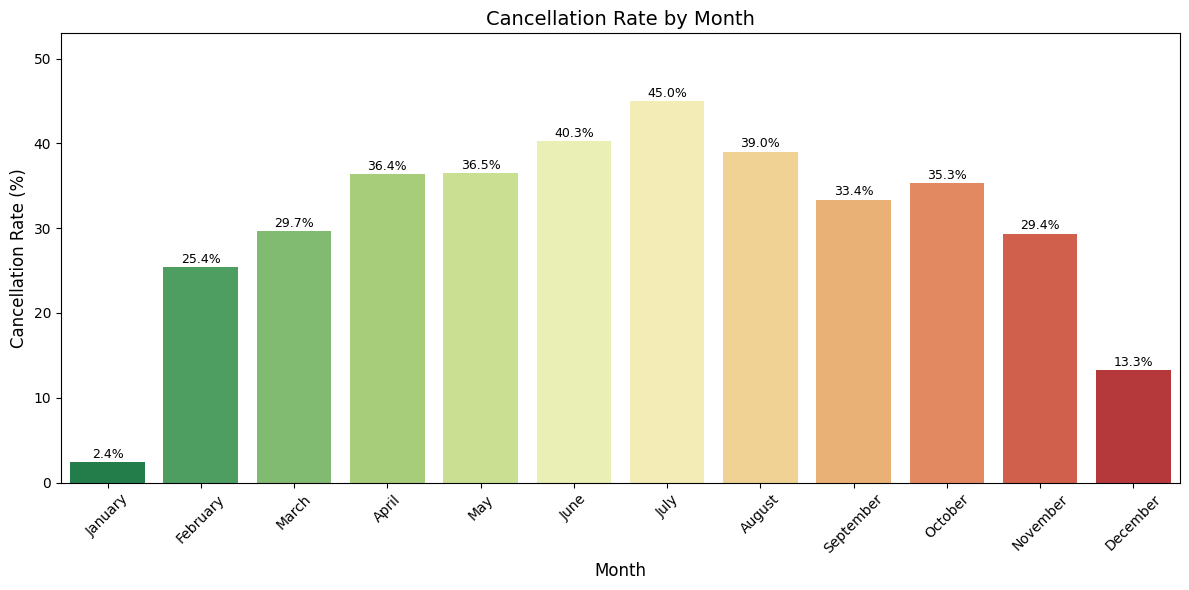

In [ ]:


plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=month_summary.index,
    y=month_summary['cancellation_rate'],
    palette='RdYlGn_r'
)


for i, value in enumerate(month_summary['cancellation_rate']):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=9)

plt.title('Cancellation Rate by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, month_summary['cancellation_rate'].max() + 8)
plt.tight_layout()
plt.show()

In [ ]:

monthly_revenue_loss = df[df['booking_status_number'] == 1].groupby('reservation_month')['potential_revenue'].agg(
    total_canceled_bookings='count',
    total_lost_revenue='sum',
    mean_lost_revenue_per_booking='mean'
).reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])


monthly_revenue_loss = monthly_revenue_loss.round(2)
monthly_revenue_loss

,total_canceled_bookings,total_lost_revenue,mean_lost_revenue_per_booking
reservation_month,,,
January,24,4603.10,191.80
February,424,119193.35,281.12
March,700,245020.61,350.03
April,996,328137.92,329.46
May,949,354648.71,373.71
June,1291,440030.57,340.84
July,1314,517431.70,393.78
August,1488,626128.28,420.79
September,1539,608044.67,395.09


/tmp/ipykernel_2268/2103871475.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


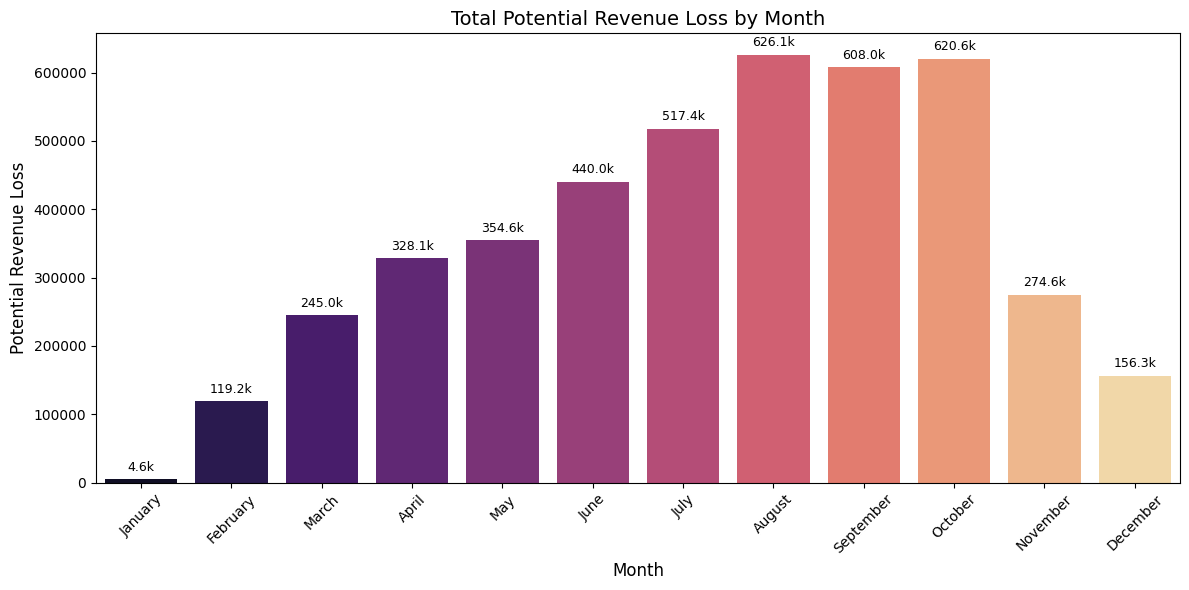

In [ ]:


plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=monthly_revenue_loss.index,
    y=monthly_revenue_loss['total_lost_revenue'],
    palette='magma'
)



for i, value in enumerate(monthly_revenue_loss['total_lost_revenue']):
    ax.text(i, value + (monthly_revenue_loss['total_lost_revenue'].max() * 0.02),
            f'{value/1000:.1f}k', ha='center', fontsize=9, rotation=0)

plt.title('Total Potential Revenue Loss by Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Potential Revenue Loss', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight: Cancellation Volume vs. Financial Loss

* **Operational Risk:** October has the highest number of canceled bookings, with **1,880 cancellations**. Therefore, it creates the highest operational pressure in terms of capacity planning and inventory management.
* **Financial Risk:** August has the highest total potential revenue loss, equal to **626,128.28**, despite having fewer cancellations than October.
* **Key Explanation:** The average potential revenue per canceled booking is higher in August (**420.79**) than in October (**330.10**).
* **Interpretation:** Cancellation risk should not be evaluated only by cancellation rate or cancellation volume. The financial value of canceled bookings must also be considered.
* **Business Recommendation:** October requires stronger volume and capacity management, while August and July require greater protection for high-value reservations through deposits, non-refundable rates, and targeted confirmation campaigns.
* **Caveat:** `potential_revenue` is an estimate based on `total_nights × average_price`; it does not necessarily represent actual realized revenue or final financial loss.

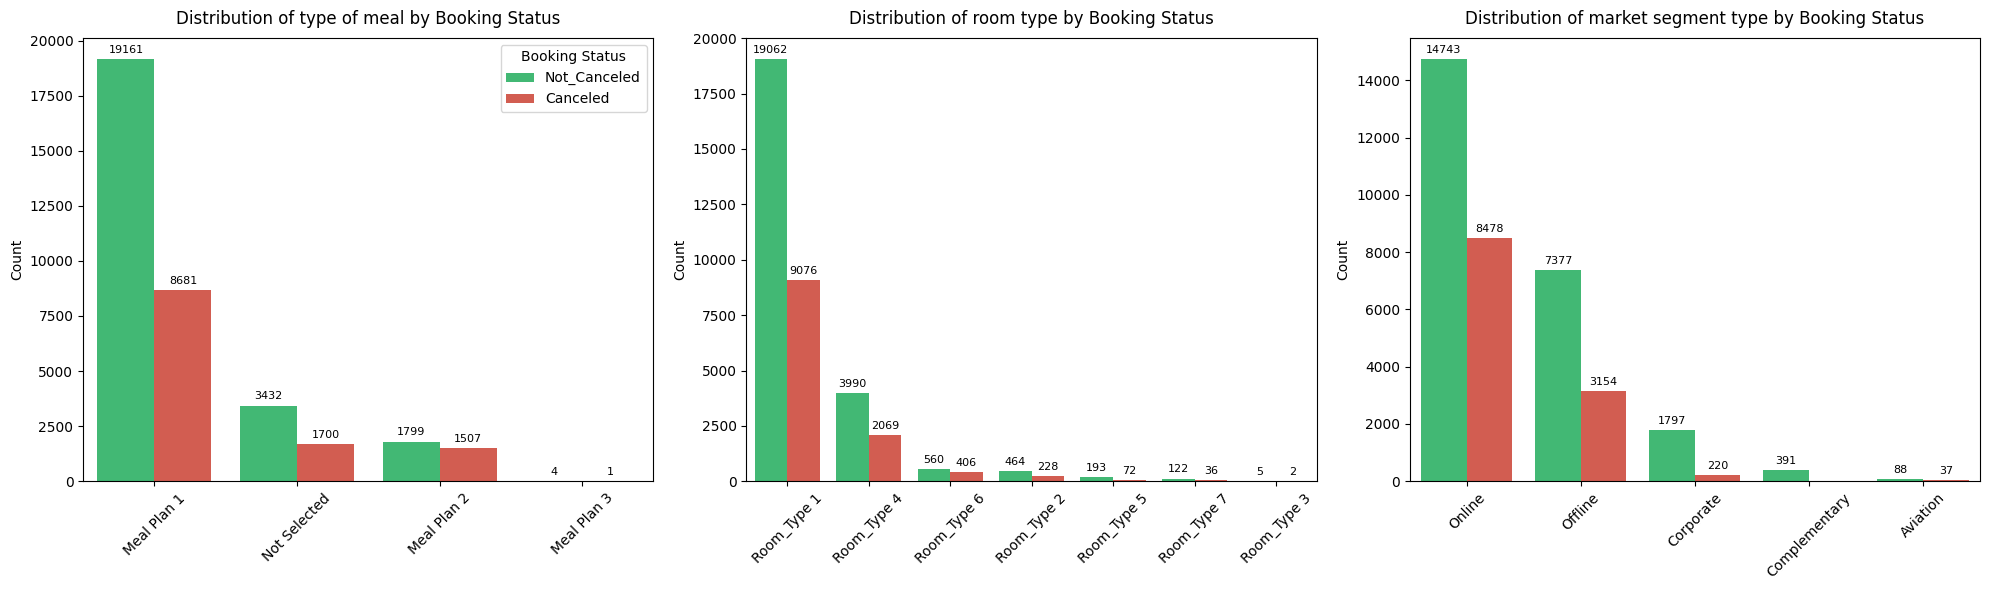

In [ ]:


categorical_cols = ['type of meal', 'room type', 'market segment type']


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='booking status',
        ax=axes[i],
        palette={'Not_Canceled': '#2ecc71', 'Canceled': '#e74c3c'},
        order=df[col].value_counts().index
    )
    axes[i].set_title(f'Distribution of {col} by Booking Status', fontsize=12, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)


    for p in axes[i].patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            axes[i].annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                textcoords='offset points'
            )


    if i == 0:
        axes[i].legend(title='Booking Status', loc='upper right')
    else:
        axes[i].legend().remove()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2268/996620101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_2268/996620101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_2268/996620101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


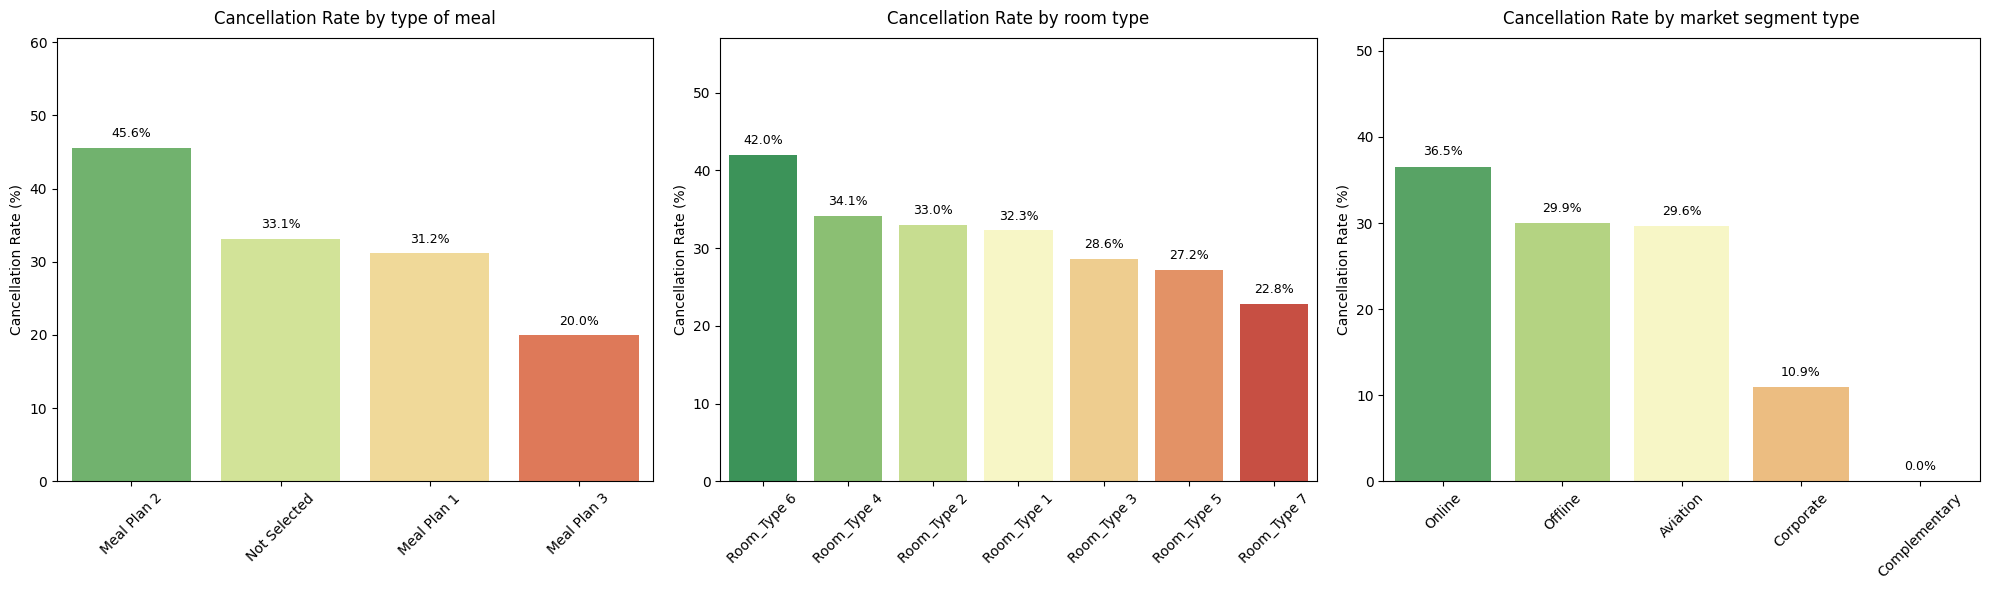

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(categorical_cols):

    rates = (
        df.groupby(col)['booking_status_number']
          .mean()
          .mul(100)
          .round(2)
          .sort_values(ascending=False)
    )


    ax = axes[i]
    bars = sns.barplot(
        x=rates.index,
        y=rates.values,
        ax=ax,
        palette='RdYlGn_r'
    )

    ax.set_title(f'Cancellation Rate by {col}', fontsize=12, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Cancellation Rate (%)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, rates.max() + 15)   # فضای اضافه برای برچسب‌ها


    for bar, val in zip(bars.patches, rates.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            val + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

## Categorical Analysis Summary

In this section, three categorical columns were analyzed:

- `type of meal`
- `room type`
- `market segment type`

### Main Findings
- `Meal Plan 2` has the highest cancellation rate among meal types.
- `Room_Type 6` has the highest cancellation rate among room types.
- `Online` has the highest cancellation rate among market segments.
- `Complementary` shows the lowest cancellation rate, but its sample size is small.

### Initial Interpretation
These results are only initial statistical signals and do not prove the real cause of cancellations.  
The observed patterns may be influenced by other factors such as `lead_time`, `customer type`, `deposit type`, and `average price`.

### Next Step
These columns should be analyzed together with other variables to identify the stronger factors behind booking cancellations.

#Lead Time and Cancellation Rate Analysis

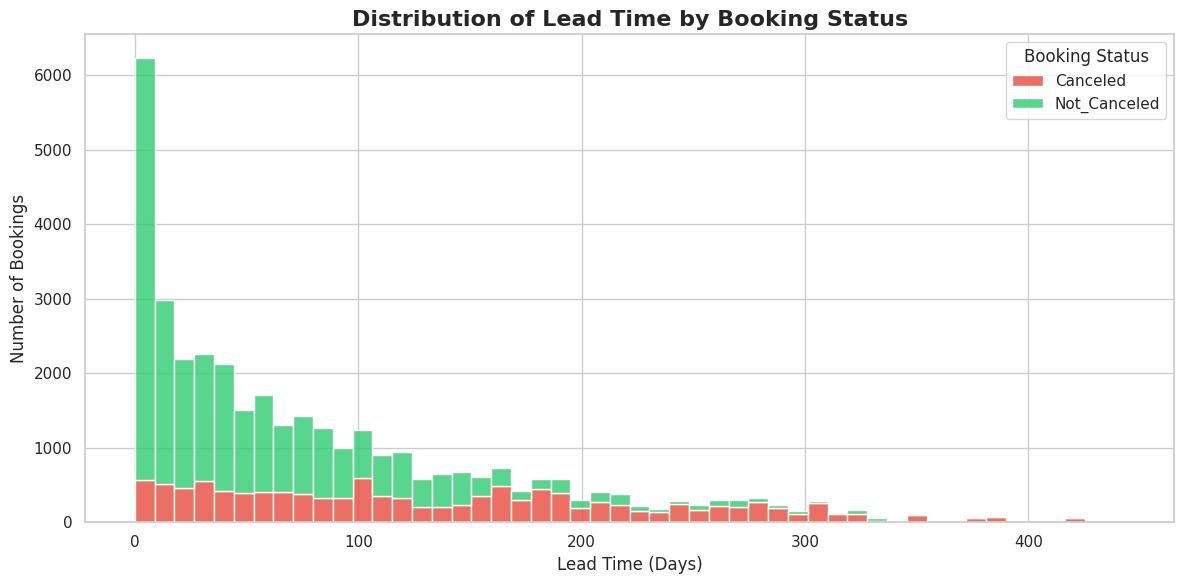

In [ ]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))


ax = sns.histplot(
    data=df,
    x="lead time",
    hue="booking status",
    multiple="stack",
    palette={"Not_Canceled": "#2ecc71", "Canceled": "#e74c3c"},
    bins=50,
    edgecolor="white",
    alpha=0.8
)

plt.title("Distribution of Lead Time by Booking Status", fontsize=16, fontweight='bold')
plt.xlabel("Lead Time (Days)", fontsize=12)
plt.ylabel("Number of Bookings", fontsize=12)
plt.legend(title="Booking Status", labels=["Canceled", "Not_Canceled"])
plt.tight_layout()
plt.show()

## Lead Time Analysis

`Lead time` shows the number of days between the reservation date and the arrival date.

The distribution of `lead time` is right-skewed. Most bookings were made a short time before arrival, while a smaller number had very long lead times.

The cancellation rate increases as `lead time` becomes longer:

- **0–50 days:** 17.55%
- **101–150 days:** 38.31%
- **151–200 days:** 67.52%
- **301–400 days:** 79.47%
- **+400 days:** 100%

Overall, longer lead times are strongly associated with higher cancellation rates. However, this relationship shows correlation, not causation. Other factors, such as `deposit type`, `customer type`, `market segment type`, and `average price`, may also affect cancellations.

**Business Recommendation:**  
Bookings with long lead times should be monitored more carefully. Hotels can reduce cancellation risk by sending reminder messages, requesting partial deposits, and offering flexible but controlled cancellation policies for early bookings.

The `+400` group contains only 102 bookings, so its 100% cancellation rate should be interpreted cautiously.

## Lead Time and Meal Plan Relationship Analysis

In [ ]:

df["lead time"] = pd.to_numeric(
    df["lead time"],
    errors="coerce"
)


bins = [0, 50, 100, 150, 200, 300, 400, 600, np.inf]

labels = [
    "0-50",
    "51-100",
    "101-150",
    "151-200",
    "201-300",
    "301-400",
    "401-600",
    "+600"
]


df["lead_time_group"] = pd.cut(
    df["lead time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


analysis_lead_time_group = (
    df.groupby(
        "lead_time_group",
        observed=False,
        dropna=False
    )
    .agg(
        total_bookings=("booking_status_number", "size"),
        total_canceled=("booking_status_number", "sum"),
        cancellation_rate=("booking_status_number", "mean")
    )
    .assign(
        cancellation_rate=lambda x: (
            x["cancellation_rate"]
            .mul(100)
            .round(2)
        )
    )
    .reset_index()
)


display(
    analysis_lead_time_group.style
        .format({
            "total_bookings": "{:,}",
            "total_canceled": "{:,}",
            "cancellation_rate": "{:.2f}%"
        })
        .background_gradient(
            subset=["cancellation_rate"],
            cmap="Reds"
        )
)

,lead_time_group,total_bookings,total_canceled,cancellation_rate
0,0-50,"16,866","2,801",16.61%
1,51-100,"7,525","2,105",27.97%
2,101-150,"4,610","1,766",38.31%
3,151-200,"3,159","2,133",67.52%
4,201-300,"3,000","2,169",72.30%
5,301-400,"1,023",813,79.47%
6,401-600,102,102,100.00%
7,+600,0,0,nan%


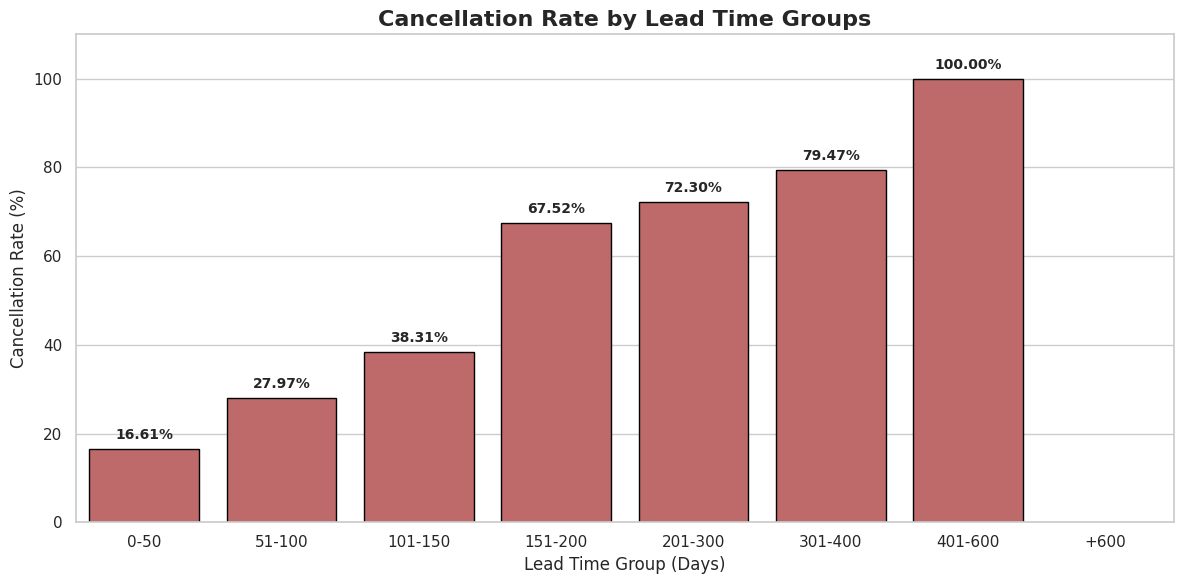

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=analysis_lead_time_group,
    x="lead_time_group",
    y="cancellation_rate",
    color="indianred",
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "Cancellation Rate by Lead Time Groups",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Lead Time Group (Days)", fontsize=12)
ax.set_ylabel("Cancellation Rate (%)", fontsize=12)
ax.set_ylim(0, 110)


for bar in ax.patches:
    height = bar.get_height()

    if pd.notna(height):
        ax.annotate(
            f"{height:.2f}%",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [ ]:

df.groupby("type of meal").agg(
    total_customer=("lead time", "count"),
    total_canceled=("booking_status_number", "sum"),
    median_lead_time=("lead time", "median")
)

,total_customer,total_canceled,median_lead_time
type of meal,,,
Meal Plan 1,27842,8681,57.0
Meal Plan 2,3306,1507,102.0
Meal Plan 3,5,1,4.0
Not Selected,5132,1700,36.0


In [ ]:





meal_lead_analysis = (
    df.groupby(["type of meal", "Lead_time_group"], observed=False)
      .agg(
          total_bookings=("booking_status_number", "count"),
          canceled_bookings=("booking_status_number", "sum"),
          cancellation_rate=("booking_status_number", "mean")
      )
      .reset_index()
)

meal_lead_analysis["cancellation_rate"] *= 100

meal_lead_analysis

,type of meal,Lead_time_group,total_bookings,canceled_bookings,cancellation_rate
0,Meal Plan 1,0-50,12098,1973,16.308481
1,Meal Plan 1,51-100,5811,1610,27.706075
2,Meal Plan 1,101-150,3544,1260,35.553047
3,Meal Plan 1,150-200,2646,1752,66.213152
4,Meal Plan 1,201-300,2149,1518,70.637506
5,Meal Plan 1,301-400,590,448,75.932203
6,Meal Plan 1,+400,67,67,100.000000
7,Meal Plan 2,0-50,746,115,15.415550
8,Meal Plan 2,51-100,708,118,16.666667
9,Meal Plan 2,101-150,546,259,47.435897


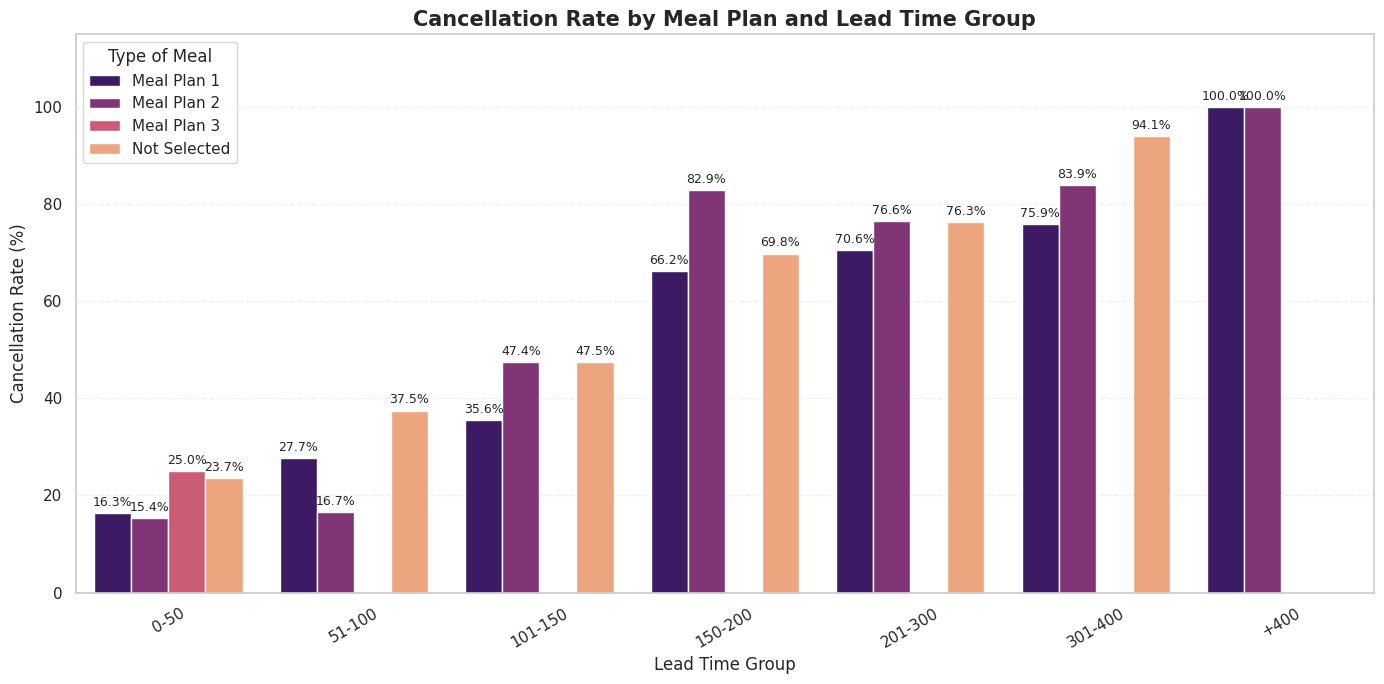

In [ ]:

plot_data = meal_lead_analysis.dropna(
    subset=["cancellation_rate"]
).copy()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=plot_data,
    x="Lead_time_group",
    y="cancellation_rate",
    hue="type of meal",
    palette="magma",
    errorbar=None
)


for container in ax.containers:
    labels = []

    for bar in container:
        height = bar.get_height()

        if height > 0:
            labels.append(f"{height:.1f}%")
        else:
            labels.append("")

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.title(
    "Cancellation Rate by Meal Plan and Lead Time Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Lead Time Group", fontsize=12)
plt.ylabel("Cancellation Rate (%)", fontsize=12)

plt.ylim(0, 115)
plt.xticks(rotation=30)
plt.legend(title="Type of Meal")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis of Lead Time and Meal Plan

### Goal

The goal of this analysis is to examine the relationship between `lead time`, `type of meal`, and booking cancellations. In particular, we want to determine whether bookings made further in advance are associated with higher cancellation rates for different meal plans.

---

### Overall Lead Time Analysis

The distribution of `lead time` is right-skewed. Most bookings are made relatively close to the arrival date, while a smaller number of bookings are made several months or more than one year in advance.

The cancellation rate increases substantially as `lead time` increases:

| Lead Time Group | Cancellation Rate |
|---|---:|
| 0–50 days | 17.55% |
| 151–200 days | 67.52% |
| 301–400 days | 79.47% |
| 400+ days | 100.00% |

These results suggest a strong positive association between longer lead times and cancellation risk. However, the `400+` group should be interpreted carefully because it contains a relatively small number of bookings.

---

### Meal Plan Summary

| Type of Meal | Total Bookings | Canceled Bookings | Cancellation Rate | Median Lead Time |
|---|---:|---:|---:|---:|
| Meal Plan 1 | 27,842 | 8,681 | 31.18% | 57 days |
| Meal Plan 2 | 3,306 | 1,507 | 45.59% | 102 days |
| Meal Plan 3 | 5 | 1 | 20.00% | 4 days |
| Not Selected | 5,132 | 1,700 | 33.13% | 36 days |

`Meal Plan 2` has both the highest cancellation rate and the highest median lead time.

The cancellation rate for `Meal Plan 2` is 45.59%, compared with 31.18% for `Meal Plan 1` and 33.13% for bookings where no meal plan was selected.

Its median lead time is 102 days, which is considerably higher than the median lead time for `Meal Plan 1` and `Not Selected`.

---

### Cancellation Rate of Meal Plan 2 by Lead Time

| Lead Time Group | Total Bookings | Canceled Bookings | Cancellation Rate |
|---|---:|---:|---:|
| 0–50 days | 746 | 115 | 15.42% |
| 51–100 days | 708 | 118 | 16.67% |
| 101–150 days | 546 | 259 | 47.44% |
| 151–200 days | 175 | 145 | 82.86% |
| 201–300 days | 632 | 484 | 76.58% |
| 301–400 days | 416 | 349 | 83.89% |
| 400+ days | 35 | 35 | 100.00% |

For `Meal Plan 2`, the cancellation rate is relatively low for bookings made within 100 days of arrival. However, it increases sharply when the lead time exceeds 100 days.

The cancellation rate reaches more than 76% for bookings with lead times above 150 days. This indicates that long-lead-time bookings under `Meal Plan 2` are associated with a significantly higher cancellation risk.

The small decrease from 82.86% in the `151–200` group to 76.58% in the `201–300` group does not invalidate the overall pattern. Cancellation rates do not always increase perfectly in every individual group.

---

### Interpretation

The results show that `Meal Plan 2` is associated with:

1. A longer booking horizon, with a median lead time of 102 days.
2. The highest overall cancellation rate, at 45.59%.
3. A sharp increase in cancellation rate when the lead time exceeds 100 days.
4. Cancellation rates above 76% for bookings made more than 150 days in advance.

Therefore, the data supports the following conclusion:

> Bookings associated with `Meal Plan 2` tend to be made earlier and have a higher cancellation rate, especially when the lead time is long.

However, this analysis does not prove that `lead time` independently causes cancellations. Other variables, such as `deposit type`, `market segment`, `customer type`, `distribution channel`, price, and seasonality, may also influence the relationship.

A suitable analytical statement is:

> `Meal Plan 2` is associated with both longer lead times and higher cancellation rates. The increase in cancellation rates across lead-time groups suggests that long lead times may contribute to cancellation risk, but causality cannot be confirmed without controlling for other variables.

---

### Business Recommendations

Based on these findings, the hotel could apply the following strategies:

#### 1. Risk-based booking policies

Bookings under `Meal Plan 2` with lead times above 100 or 150 days could be classified as higher-risk reservations.

The hotel could apply:

- Stricter cancellation policies.
- Advance payment requirements.
- Credit card guarantees.
- Partial non-refundable deposits.

#### 2. Automated reminders

The hotel could send automated reminders to customers who booked `Meal Plan 2` far in advance.

Possible reminder times include:

- Immediately after booking.
- 60 days before arrival.
- 30 days before arrival.
- 7 days before arrival.

#### 3. Non-refundable alternatives

The hotel could offer a discounted non-refundable rate for customers who book `Meal Plan 2` far in advance.

This may help convert uncertain reservations into more committed bookings.

#### 4. Targeted customer communication

Customers with long lead times could receive:

- Confirmation messages.
- Payment reminders.
- Clear cancellation-policy explanations.
- Easy options to modify their booking instead of cancelling it.

#### 5. Further investigation of related variables

The hotel should compare `Meal Plan 2` bookings by:

- `deposit type`
- `market segment`
- `customer type`
- `distribution channel`
- `average price`
- `hotel type`
- seasonality

This can help determine whether the high cancellation rate is related to the meal plan itself or to the customer groups and booking channels associated with it.

---

### Suggested Visualizations

The following visualizations are useful for this analysis:

- Bar chart of cancellation rate by `type of meal`.
- Bar chart of median `lead time` by `type of meal`.
- Line chart of cancellation rate by `lead_time_group` for each meal plan.
- Heatmap showing the number of bookings by meal plan and lead-time group.
- Stacked bar chart showing canceled and non-canceled bookings by meal plan.

---

### Limitations

- `Meal Plan 3` contains only 5 bookings, so its cancellation rate is not reliable for comparison.
- The `400+` lead-time group for `Meal Plan 2` contains only 35 bookings.
- Some lead-time groups have considerably different sample sizes.
- The analysis shows association, not causation.
- The effect of other variables has not yet been controlled.
- The results should be validated with multivariate analysis, such as logistic regression.

## Lead Time and Room Type Relationship Analysis

In [ ]:

df.groupby("room type").agg(
    total_customer=("lead time", "count"),
    total_canceled=("booking_status_number", "sum"),
    median_lead_time=("lead time", "median")
)

,total_customer,total_canceled,median_lead_time
room type,,,
Room_Type 1,28138,9076,59.0
Room_Type 2,692,228,75.0
Room_Type 3,7,2,66.0
Room_Type 4,6059,2069,55.0
Room_Type 5,265,72,32.0
Room_Type 6,966,406,38.0
Room_Type 7,158,36,20.5


In [ ]:
room_lead_analysis = (
    df.groupby(["room type", "Lead_time_group"], observed=False)
      .agg(
          total_bookings=("booking_status_number", "count"),
          canceled_bookings=("booking_status_number", "sum"),
          cancellation_rate=("booking_status_number", "mean")
      )
      .reset_index()
)

room_lead_analysis["cancellation_rate"] *= 100

room_lead_analysis

,room type,Lead_time_group,total_bookings,canceled_bookings,cancellation_rate
0,Room_Type 1,0-50,11872,1851,15.591307
1,Room_Type 1,51-100,5445,1416,26.005510
2,Room_Type 1,101-150,3435,1293,37.641921
3,Room_Type 1,150-200,2574,1670,64.879565
4,Room_Type 1,201-300,2648,1906,71.978852
5,Room_Type 1,301-400,992,791,79.737903
6,Room_Type 1,+400,102,102,100.000000
7,Room_Type 2,0-50,269,43,15.985130
8,Room_Type 2,51-100,108,25,23.148148
9,Room_Type 2,101-150,106,24,22.641509


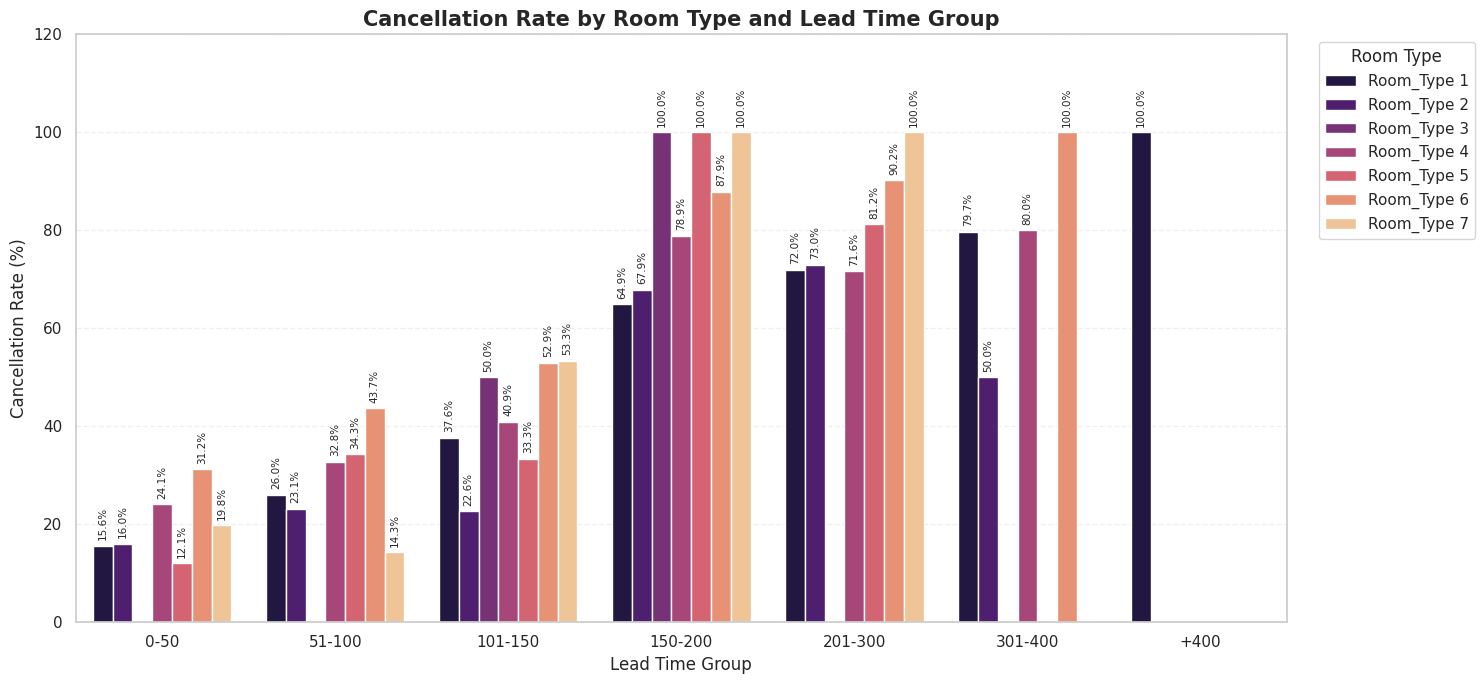

In [ ]:


plot_data = room_lead_analysis.dropna(subset=["cancellation_rate"]).copy()

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=plot_data,
    x="Lead_time_group",
    y="cancellation_rate",
    hue="room type",
    palette="magma",
    errorbar=None
)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        labels.append(f"{height:.1f}%" if height > 0 else "")
    ax.bar_label(
        container,
        labels=labels,
        padding=4,
        fontsize=7.5,
        rotation=90
    )

plt.title(
    "Cancellation Rate by Room Type and Lead Time Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Lead Time Group", fontsize=12)
plt.ylabel("Cancellation Rate (%)", fontsize=12)
plt.ylim(0, 120)
plt.xticks(rotation=0)
plt.legend(title="Room Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Room_Type 6 has the highest overall cancellation rate, at 42.0%, although its median lead time is only 38 days. This indicates that the high cancellation rate of Room_Type 6 cannot be explained simply by a generally longer booking horizon.

However, when cancellation rates are examined within lead-time groups, a clear increasing pattern can be observed. The cancellation rate rises from 31.25% for bookings made 0–50 days before arrival to 87.88% for bookings made 151–200 days in advance and 90.24% for bookings made 201–300 days in advance.

These results suggest that long lead times are associated with a substantially higher cancellation risk for Room_Type 6. Therefore, lead time may help explain why Room_Type 6 has a high cancellation rate, but it is probably not the only contributing factor.

From a business perspective, the hotel could classify Room_Type 6 bookings with lead times longer than 100 or 150 days as high-risk reservations. For these bookings, the hotel could use automated reminders, request a deposit or credit-card guarantee, offer non-refundable rates, and provide flexible date-change options instead of allowing complete cancellation.

The hotel should also investigate other variables, such as `deposit type`, `market segment`, `customer type`, and `distribution channel`, to identify the additional factors associated with the high cancellation rate of Room_Type 6.